In [1]:
include("source_ed.jl")
using SparseArrays
using LinearAlgebra

In [2]:
@inline function idx3d(X::Int, Y::Int, Z::Int, Lx::Int, Ly::Int, Lz::Int)
    return ((Z - 1) * Ly + (Y - 1)) * Lx + X
end

@inline function f4_from_global(X::Int)
    a = mod(X - 1, 4)
    return (a == 0 || a == 3) ? 1.0 : -1.0
end

function build_hamiltonian_octupole_global(
    Lx::Int, Ly::Int, Lz::Int;
    tx1=1.0, tx2=1.6,
    ty1=1.0, ty2=1.6,
    tz1=1.0, tz2=1.6,
    λ=0.0,
    β1=1/4, β2=1/4, β3=1/4,
    ϕ=pi/4,
    sparse::Bool=true
)

    dim = Lx * Ly * Lz
    H = sparse ? spzeros(ComplexF64, dim, dim) : zeros(ComplexF64, dim, dim)

    @inline function add_hop!(i::Int, j::Int, t::Number)
        H[i, j] += ComplexF64(t)
        H[j, i] += ComplexF64(t)
    end

    for X in 1:Lx, Y in 1:Ly, Z in 1:Lz
        i = idx3d(X, Y, Z, Lx, Ly, Lz)

        # Original unit-cell coordinates x, y, z
        cx = div(X - 1, 4) + 1
        cy = div(Y - 1, 4) + 1
        cz = div(Z - 1, 4) + 1

        Vx = cos(2π * β1 * (cx - 1) + ϕ)
        Vy = cos(2π * β2 * (cy - 1) + ϕ)
        Vz = cos(2π * β3 * (cz - 1) + ϕ)
        Venv = Vx * Vy * Vz * sqrt(2)

        η = f4_from_global(X) * f4_from_global(Y) * f4_from_global(Z)

        H[i, i] += 1im * 2 * λ *  Venv * η

        # x hopping
        if X < Lx
            j = idx3d(X + 1, Y, Z, Lx, Ly, Lz)
            t = iseven(X - 1) ? tx1 : tx2
            add_hop!(i, j, t)
        end

        # y hopping
        if Y < Ly
            j = idx3d(X, Y + 1, Z, Lx, Ly, Lz)
            signy = iseven(X - 1) ? 1.0 : -1.0
            t = iseven(Y - 1) ? ty1 : ty2
            add_hop!(i, j, signy * t)
        end

        # z hopping
        if Z < Lz
            j = idx3d(X, Y, Z + 1, Lx, Ly, Lz)
            signz = iseven((X - 1) + (Y - 1)) ? 1.0 : -1.0
            t = iseven(Z - 1) ? tz1 : tz2
            add_hop!(i, j, signz * t)
        end
    end

    return H
end


build_hamiltonian_octupole_global (generic function with 1 method)

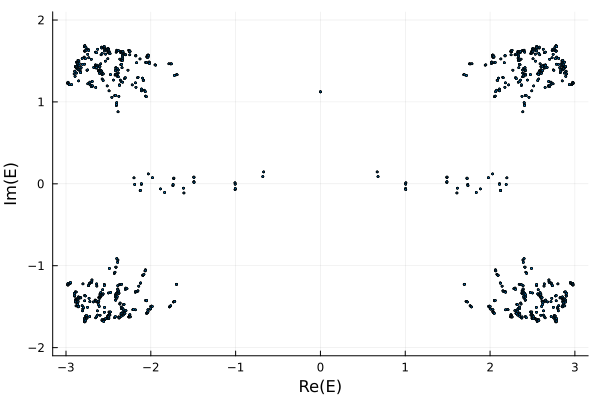

In [4]:
Nx, Ny, Nz = 16,16,16

H = build_hamiltonian_octupole_global(Nx, Ny, Nz;
    tx1=1.  , tx2=1.4 ,
    ty1=1. , ty2 =1.4,
    tz1=1 , tz2= 1.4
    ,
    λ=2,
    sparse=true
);

ymax = 2.1
ev = eigvals(Matrix(H))
p = scatter(real.(ev), imag.(ev),
    ms=1,
    xlabel="Re(E)",
    ylabel="Im(E)",
    ylims=(-ymax, ymax),
    legend=false
)
display(p)
